# Phase 2 — full time-series extraction

Extracts every block in `data/blocks.geojson`, full calendar year (Jan–Dec),
2019 → present, into `data/processed/block_timeseries.parquet` matching the
data contract:

`block_id, date, scene_id, ndvi_median, ndvi_p10, ndvi_p90, ndre_median, valid_frac`

Extraction is not restricted to the April–October growing season — dormant
months are pulled too so the annual curve has real data everywhere, not just
whitespace. Analysis code filters to the season window itself if that's what
it wants; the raw table stores everything.

All Earth Engine work is server-side in `vigor.extract` (one `reduceRegions`
per scene per resolution — 10 m NDVI stats chained into 20 m NDRE — no Python
loop over scenes, no `getInfo` in loops); results come back via a Drive
export. The same code path serves any number of blocks; if the table
outgrows `getInfo` even for a small block set, the Drive path is already the
one in use here.

**Acceptance criteria (Phase 2):**
- Curves show correct phenology: dormant 0.15–0.25, May green-up,
  July–August plateau, October decline.
- 2024 shows delayed green-up or depressed peaks exactly in the blocks with
  known January 2024 freeze damage — the most important validation in the project.

In [1]:
import sys
from pathlib import Path

import pandas as pd

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT / "src"))

from vigor import extract, ingest, plots

RAW_CSV = PROJECT_ROOT / "data" / "raw" / "block_timeseries_raw.csv"
FIXTURE_CSV = PROJECT_ROOT / "tests" / "fixtures" / "sample_extract.csv"
PARQUET = PROJECT_ROOT / "data" / "processed" / "block_timeseries.parquet"
FIGURES = PROJECT_ROOT / "outputs" / "figures"

In [2]:
extract.init_ee()

In [3]:
blocks = extract.load_blocks(PROJECT_ROOT / "data" / "blocks.geojson")
blocks[["block_id", "site", "variety", "planting_year", "area_ha", "n_pixels"]]

,block_id,site,variety,planting_year,area_ha,n_pixels
0,penticton-ub-b1,penticton,chardonnay,2024,3.306338,322
1,oliver-ub-b1,oliver,Merlot,2023,0.882325,83
2,1,penticton,chard,2024,3.171610,308
3,2,oliver,merlot,2024,0.919600,86


## Extraction

Builds the lazy (scene × block) table server-side, then starts one Drive
export. This avoids Earth Engine's interactive aggregation limit for the
full 2019–present archive. Once the task is complete, rerun the notebook:
the CSV is downloaded automatically and all remaining cells run locally.

In [4]:
if not RAW_CSV.exists():
    try:
        extract.download_latest_drive_csv("block_timeseries_raw.csv", RAW_CSV)
    except FileNotFoundError:
        table = extract.timeseries_table(blocks)
        task = extract.export_table_to_drive(table, description="block_timeseries_raw")
        print(f"started Drive export {task.id}; wait for COMPLETED, then rerun this notebook")
        raise RuntimeError("Extraction is running in Earth Engine. Rerun after the Drive task completes.")

raw = pd.read_csv(RAW_CSV)
print(f"using local raw table: {len(raw)} rows, {raw['date'].min()} to {raw['date'].max()}")

raw.head()

using local raw table: 2684 rows, 2019-04-03 to 2026-07-15


,block_id,date,scene_id,ndvi_median,ndvi_p10,ndvi_p90,ndre_median,valid_count,total_count
0,penticton-ub-b1,2019-04-03,20190403T190121_20190403T190252_T10UGV,NaN,NaN,NaN,NaN,0,289
1,oliver-ub-b1,2019-04-03,20190403T190121_20190403T190252_T10UGV,NaN,NaN,NaN,NaN,0,59
2,penticton-ub-b1,2019-04-03,20190403T190121_20190403T190252_T11ULQ,NaN,NaN,NaN,NaN,0,289
3,oliver-ub-b1,2019-04-03,20190403T190121_20190403T190252_T11ULQ,NaN,NaN,NaN,NaN,0,59
4,penticton-ub-b1,2019-04-05,20190405T184919_20190405T190035_T10UGV,NaN,NaN,NaN,NaN,0,289


In [5]:
RAW_CSV.parent.mkdir(parents=True, exist_ok=True)
FIXTURE_CSV.parent.mkdir(parents=True, exist_ok=True)
raw.to_csv(RAW_CSV, index=False)
raw.to_csv(FIXTURE_CSV, index=False)
print(f"raw table -> {RAW_CSV}")
print(f"test fixture -> {FIXTURE_CSV}")

raw table -> C:\Users\brylan\Desktop\ML vineyard\vineyard-vigor\data\raw\block_timeseries_raw.csv
test fixture -> C:\Users\brylan\Desktop\ML vineyard\vineyard-vigor\tests\fixtures\sample_extract.csv


In [6]:
ts = ingest.raw_to_timeseries(raw)
ingest.write_timeseries(ts, PARQUET)
print(f"parquet -> {PARQUET}\n")

summary = ts.groupby("block_id").agg(
    rows=("date", "size"),
    usable=("valid_frac", lambda s: int((s >= ingest.MIN_VALID_FRAC).sum())),
    first=("date", "min"),
    last=("date", "max"),
)
summary

parquet -> C:\Users\brylan\Desktop\ML vineyard\vineyard-vigor\data\processed\block_timeseries.parquet



,rows,usable,first,last
block_id,,,,
oliver-ub-b1,1342,829,2019-04-03,2026-07-15
penticton-ub-b1,1342,761,2019-04-03,2026-07-15


## Multi-year NDVI curves

One panel per block, one line per year (light = oldest, dark = newest);
**2024, the freeze year, is drawn in red**. Only rows with
`valid_frac ≥ 0.8` are plotted.

Check: dormant-season shoulders 0.15–0.25, May green-up, July–August plateau,
October decline — and 2024 sitting visibly low or late where freeze damage is known.

figure -> C:\Users\brylan\Desktop\ML vineyard\vineyard-vigor\outputs\figures\02_all_ndvi_multiyear.png


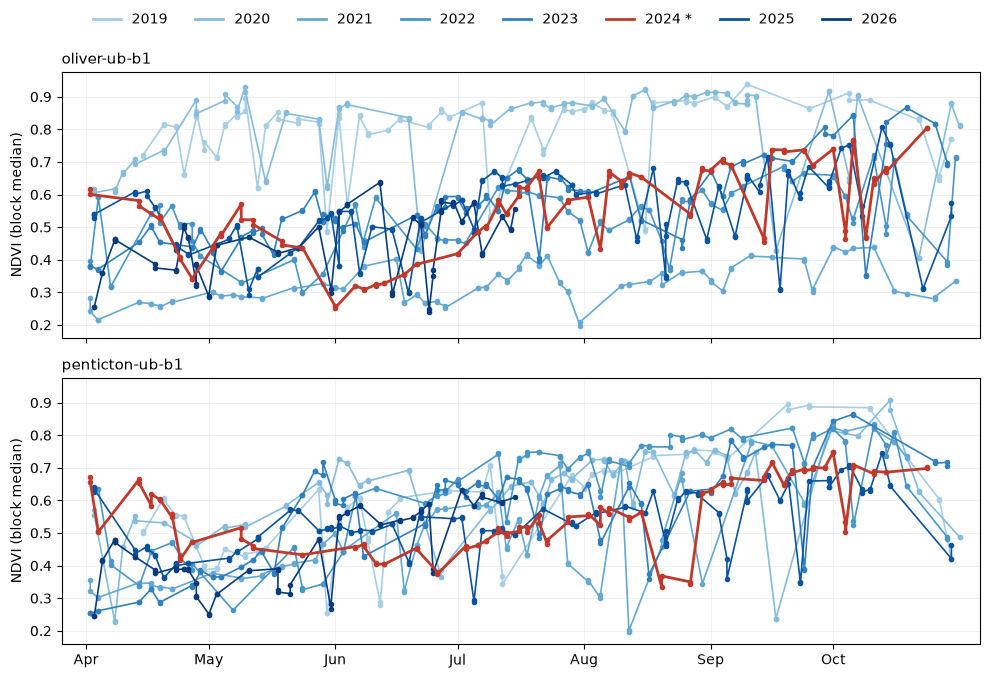

In [7]:
fig = plots.ndvi_multiyear(ts, emphasize_year=2024)
saved = plots.save_figure(fig, FIGURES / "02_all_ndvi_multiyear.png")
print(f"figure -> {saved}")

## Numeric freeze check

Median of the July block-median NDVI, per block per year — 2024 should stand
out low against each block's own history.

In [8]:
usable = ingest.analysis_view(ts)
july = usable[usable["date"].dt.month == 7]
july.groupby(["block_id", july["date"].dt.year.rename("year")])["ndvi_median"].median().unstack().round(3)

year,2019,2020,2021,2022,2023,2024,2025,2026
block_id,,,,,,,,
oliver-ub-b1,0.845,0.866,0.335,0.593,0.610,0.574,0.632,0.517
penticton-ub-b1,0.651,0.656,0.586,0.732,0.634,0.501,0.509,0.609
